In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data/cardio.csv', sep=";")
print(data.head())
print(data.shape)
print(data.max())
data = data[(data['ap_lo'] > 0) & (data['ap_lo'] < 200)] # filter
data = data[(data['ap_hi'] > 0) & (data['ap_hi'] < 200)] # filter
print("shape after filter ", data.shape)
data_np = data.to_numpy()
print(data_np)
print(data_np.shape)

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
id             99999.0
age            23713.0
gender             2.0
height           250.0
weight           200.0
ap_hi          16020.0
ap_lo          11000.0
cholesterol        3.0
gluc               3.0
smoke              1.0
alco               1.0
active             1.0
cardio             1.0
dtype: float64
shape after filter  (68836, 13)
[[0.0

In [3]:
def MSE(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

def BCE(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

def train_test_split(x, y=None, split_size=1, seed=None):
    if x.shape[0] != y.shape[0] and y is not None:
        raise ValueError(f"You trying to split {x.shape[0]} data and {y.shape[0]} data")

    rng = np.random.default_rng(seed)
    indices = rng.permutation(x.shape[0])

    split_index = int(x.shape[0] * split_size)

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    x_train = x[train_indices]
    x_test = x[test_indices]

    if y is not None:
        y_train = y[train_indices]
        y_test = y[test_indices]

        return x_train, x_test, y_train, y_test
    else:
        return x_train, x_test

def numpy_confusion_matrix(y_true, y_pred, num_classes=None):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel().astype(int)

    # Determine the number of classes
    if num_classes is None:
        num_classes = max(max(y_true), max(y_pred)) + 1

    tp = true_positive = np.sum((y_true == 1) & (y_pred == 1))
    tn = true_negative = np.sum((y_true == 0) & (y_pred == 0))
    fp = false_positive = np.sum((y_true == 0) & (y_pred == 1))
    fn = false_negative = np.sum((y_true == 1) & (y_pred == 0))

    cm = np.array([ [tn, fp],
                    [fn, tp]])

    # Create an easy-to-read table
    table = pd.DataFrame(
        cm,
        index=[f"Actual {'Positive' if i==0 else 'Negative'}" for i in range(num_classes)],
        columns=[f"Predicted {'Positive' if i==0 else 'Negative'}" for i in range(num_classes)]
    )

    print("\nConfusion Matrix:")
    print(table)

    accuracy = (tp + tn) / np.sum(cm)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

    print(f"\nTotal Predictions: {np.sum(cm)}")
    print(f"Correct Predictions: {np.trace(cm)}")
    print(f"Incorrect Predictions: {np.sum(cm) - np.trace(cm)}")

    return cm

In [4]:
class layer_struct:
    def __init__(self, X, y):
        print("The layer structure has been created")
        self.accepted_activation = ["None", "ReLU", "Sigmoid"]

        self.num_feature = X.shape[1]
        self.num_output = y.shape[0]

        # init layer
        self.hidden_layer = []

        # init weight
        self.weights = []

        # init train param
        self.pred = []
        self.activation = []

        # init regulation
        self.noise_injection_rate = 0
        self.dropout_rate = 0
        self.drop_point = []

    # ----------- Setting

    # Add hidden layer with units
    def add_hidden_layer(self, num_units:int, activation:str = "None"):
        if activation not in self.accepted_activation:
            raise ValueError(f"The activation function '{activation}' does not supported, please use the acceptance activation function {accepted_activation}")

        self.hidden_layer.append([activation, num_units])
        print(f"Successfully add hidden layer {len(self.hidden_layer)} with {num_units} units")

    def get_cLayer(self):
        # print(f"Number of current hidden layer is {len(self.hidden_layer)}")
        return len(self.hidden_layer)

    # initial weights
    def initial_weights(self):
        weights = []
        previous_layer = self.num_feature
        for layer in self.hidden_layer:
            # this_layer_weight = np.zeros([previous_layer, layer[1]])
            this_layer_weight = np.random.randn(previous_layer, layer[1]) * np.sqrt(2 / previous_layer)
            previous_layer = layer[1]
            weights.append(this_layer_weight)

        self.weights = weights

        return weights

    def set_dropout_rate(self, rate=0):
        self.dropout_rate = rate

    def set_noise_injection_rate(self, rate=0):
        self.noise_injection_rate = rate

    def get_weights(self):
        return self.weights

    #--------- ACTIVATION FUNCTION

    def ReLU(self, data):
        return np.maximum(0, data).astype(float)

    def Sigmoid(self, data):
        return 1/(1+ np.exp(-data))

    def activation_function(self, data, activation):
        if activation == "None":
            return data
        elif activation == "ReLU":
            return self.ReLU(data)
        elif activation == "Sigmoid":
            return self.Sigmoid(data)
        else:
            raise ValueError(f"Unknown activation: {activation}")

    #--------- Derivative ACTIVATION FUNCTION

    def derivative_ReLU(self, data):
        return (data > 0).astype(float)

    def derivative_Sigmoid(self, data):
        sigmoid = self.Sigmoid(data)
        return sigmoid * (1 - sigmoid)

    def activation_derivative(self, data, activation):
        if activation == "None":
            return np.ones_like(data) # pass (not effect)
        elif activation == "ReLU":
            return self.derivative_ReLU(data)
        elif activation == "Sigmoid":
            return self.derivative_Sigmoid(data)
        else:
            raise ValueError(f"Unknown activation: {activation}")

    #-------------- Training

    def do_forward(self, x, is_trainig=True):
        current = np.array(x)

        self.pred = []
        self.activation = []
        self.drop_point = []

        last_layer = len(self.hidden_layer) - 1 #don't do last layer (output layer)

        for index, layer in enumerate(self.hidden_layer):
            # predict
            z = current @ self.weights[index]

            # activation
            a = self.activation_function(z, layer[0])

            mask = None
            if is_trainig:
                self.pred.append(z)

                if self.dropout_rate > 0 and index < last_layer:
                    # ถ้าตัดออกแล้วผลรวมต่ำเกิน ทำให้โมเดลทำนายต่ำกว่าที่คาด = ทายเป็น 1 มากกว่าที่ควรจะเป็น
                    mask = (np.random.rand(*a.shape) >= self.dropout_rate) / (1-self.dropout_rate) # น้อยกว่า rate = 0, มากกว่า rate = 1 (+ amp for not cap when predict)
                    a = a * mask
                else:
                    mask = np.ones_like(a)
                    a = a * mask
                    
                self.drop_point.append(mask)
                self.activation.append(a)

            current = a

        return current

    def backpropagate(self, x, y_true):
        errors = [None] * len(self.weights) #initial error array
        gradient = [None] * len(self.weights) #initial error array
        max_len = len(self.weights) - 1

        for index, w in enumerate(reversed(self.weights)):
            current = max_len-index

            #(y_hat - y) aj
            if index == 0: # first round = output node compare to hidden->output
                errors[current] = self.activation[current] - y_true #(y_hat - y)
                if self.drop_point[current] is not None:
                    errors[current] = errors[current] * self.drop_point[current]

                gradient[current] = (1 / y_true.shape[0]) * (self.activation[current - 1].T @ errors[current]) #error * a (activation value from hidden layer)
                

            # (y_hat - y) vj xi ReLU'(hj)
            elif index==max_len: # last round = input node compare to input->output
                a = errors[current + 1] @ self.weights[current + 1].T #(y_hat - y) * v_j
                errors[current] = a * self.activation_derivative(self.pred[current], self.hidden_layer[current][0]) # above * Derive_ReLU of h (hidden value before activation)
                if self.drop_point[current] is not None:
                    errors[current] = errors[current] * self.drop_point[current]

                gradient[current] = (1 / y_true.shape[0]) * (x.T @ errors[current]) # above * x_i

            # in case of other hidden layer
            else:
                a = errors[current + 1] @ self.weights[current + 1].T
                errors[current] = a * self.activation_derivative(self.pred[current], self.hidden_layer[current][0])
                if self.drop_point[current] is not None:
                    errors[current] = errors[current] * self.drop_point[current]

                gradient[current] = (1 / y_true.shape[0]) * (self.activation[current - 1].T @ errors[current])

        for index, w in enumerate(reversed(self.weights)):
            current = max_len-index
            self.weights[current] = w - self.learning_rate * gradient[current]

    def train(self, X, y, learning_rate, epochs, weight_inject=None):
        # Make sure y is 2D arrays
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        if y.shape[1] != self.hidden_layer[-1][1]:
            raise TypeError(f"You trying to training {y.shape[1]} layers to the output layer {self.hidden_layer[-1][1]} layers")

        self.learning_rate = learning_rate

        self.pred = []
        self.activation = []
        
        loss_history = []

        # Reinitial weights or used predefined weights
        if weight_inject is None:
            print("None create new")
            self.initial_weights()
        else:
            print("Use injected weights")
            self.weights = weight_inject

        # Training Process
        for epoch in range(epochs):
            X_in = X

            if self.noise_injection_rate > 0:
                X_in = X + np.random.normal(0, 1, X.shape) * self.noise_injection_rate

            y_pred = self.do_forward(X_in)
            loss = BCE(y, y_pred)
            self.backpropagate(X_in, y)

            loss_history.append(loss)

        return loss_history

    def predict(self, x, threshold=0.5):
        return (self.do_forward(x, False) > threshold).astype(int)

In [5]:
# data_np_max = data_np.max(axis=0)
# data_np_min = data_np.min(axis=0)

# data_np_norm = (data_np - data_np_min) / (data_np_max - data_np_min)

# x = data_np_norm[:, 1:-1]
# y = data_np_norm[:, -1]
np.random.default_rng(100)

x = data_np[:, 1:-1]
y = data_np[:, -1]
x = (x - x.mean(axis=0)) / x.std(axis=0)

x_train, x_test, y_train, y_test = train_test_split(x, y, 0.7, 100)

print(x.shape, y.shape)


(68836, 11) (68836,)


In [6]:
a = layer_struct(x, y)
a.add_hidden_layer(6, "ReLU")
a.add_hidden_layer(64, "ReLU")
a.add_hidden_layer(1, "Sigmoid")
a.set_dropout_rate(0.3)
a.set_noise_injection_rate(0.05)
a_train_history = a.train(x_train, y_train, 1, 2000)
a_y_pred = a.predict(x_test, 0.5)
numpy_confusion_matrix(y_test, a_y_pred, 2)

The layer structure has been created
Successfully add hidden layer 1 with 6 units
Successfully add hidden layer 2 with 64 units
Successfully add hidden layer 3 with 1 units
None create new

Confusion Matrix:
                 Predicted Positive  Predicted Negative
Actual Positive                7951                2561
Actual Negative                3042                7097

Accuracy: 0.7287
Precision: 0.7348
Recall: 0.7000
F1 Score: 0.7170

Total Predictions: 20651
Correct Predictions: 15048
Incorrect Predictions: 5603


array([[7951, 2561],
       [3042, 7097]])

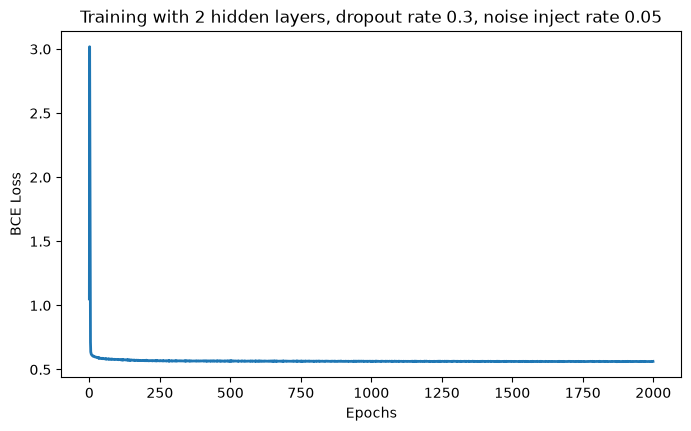

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(a_train_history)), a_train_history, lw=2, label="Train")
ax.set(xlabel='Epochs', ylabel='BCE Loss', title='Training with 2 hidden layers, dropout rate 0.3, noise inject rate 0.05')
fig.savefig("p1.png")
plt.show()

In [8]:
b = layer_struct(x, y)
b.add_hidden_layer(6, "ReLU")
b.add_hidden_layer(1, "Sigmoid")
b_train_history = b.train(x_train, y_train, 1, 2000)
b_y_pred = b.predict(x_test, 0.5)
numpy_confusion_matrix(y_test, b_y_pred, 2)

The layer structure has been created
Successfully add hidden layer 1 with 6 units
Successfully add hidden layer 2 with 1 units
None create new



Confusion Matrix:
                 Predicted Positive  Predicted Negative
Actual Positive                7779                2733
Actual Negative                2946                7193

Accuracy: 0.7250
Precision: 0.7247
Recall: 0.7094
F1 Score: 0.7170

Total Predictions: 20651
Correct Predictions: 14972
Incorrect Predictions: 5679


array([[7779, 2733],
       [2946, 7193]])

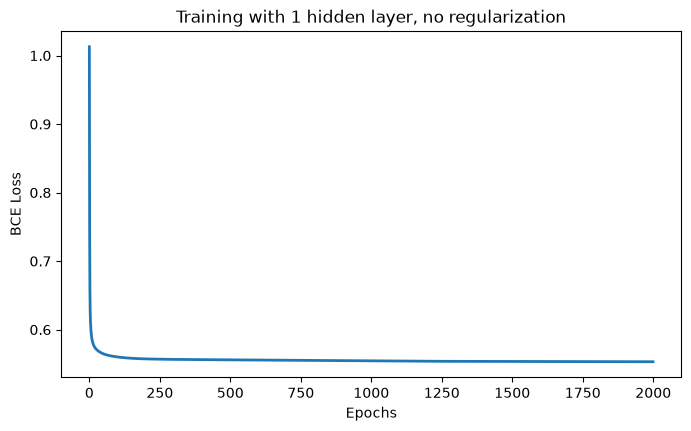

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(b_train_history)), b_train_history, lw=2, label="Train")
ax.set(xlabel='Epochs', ylabel='BCE Loss', title='Training with 1 hidden layer, no regularization')
fig.savefig("p2.png")
plt.show()

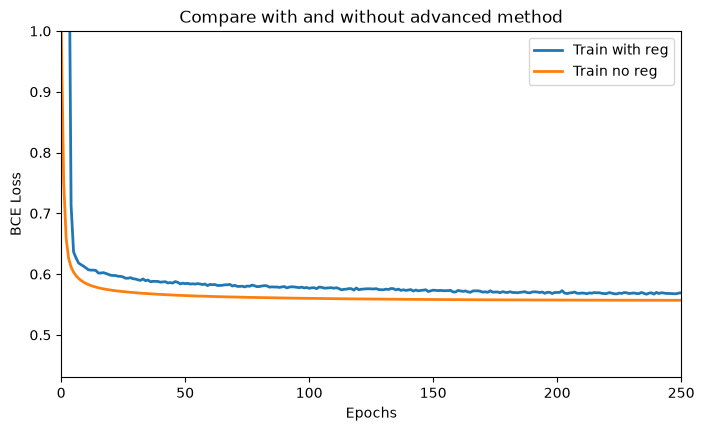

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(a_train_history)), a_train_history, lw=2, label="Train with reg")
ax.plot(np.arange(len(b_train_history)), b_train_history, lw=2, label="Train no reg")
ax.set(xlabel='Epochs', ylabel='BCE Loss', title='Compare with and without advanced method')
ax.set_ylim(top=1)
ax.set_xlim(xmax=250, xmin=0)
plt.legend()
plt.show()
fig.savefig("p4.png")

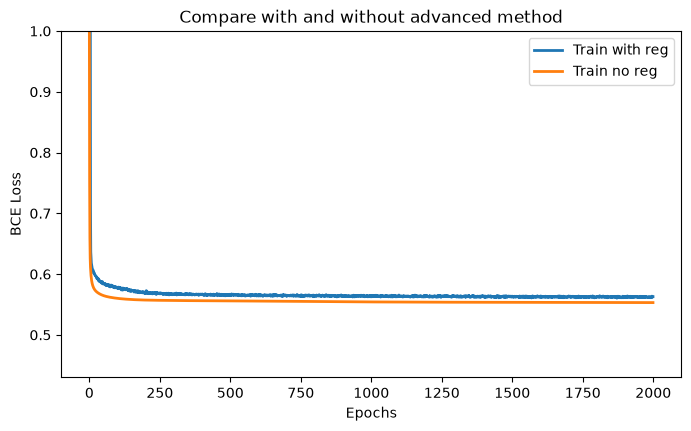

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(a_train_history)), a_train_history, lw=2, label="Train with reg")
ax.plot(np.arange(len(b_train_history)), b_train_history, lw=2, label="Train no reg")
ax.set(xlabel='Epochs', ylabel='BCE Loss', title='Compare with and without advanced method')
ax.set_ylim(top=1)
# ax.set_xlim(xmax=2000, xmin=0)
plt.legend()
plt.show()
fig.savefig("p5.png")

In [16]:
aw = a.get_weights()
bw = b.get_weights()

In [37]:
print("-------Baseline weights result\n", bw[0])
print("\n\n-------Modified version weights result\n", aw[0])

-------Baseline weights result
 [[-0.40253658  0.03163033  0.63656212 -0.62707591 -0.33808806 -0.6835918 ]
 [-0.38928716 -0.04556142  0.07676473  0.01628339 -0.02388428  0.01892369]
 [ 0.75108623  0.06090489 -0.3213044   0.17222112  0.08062947 -0.40796671]
 [-0.28932852 -0.05878423  0.36521793 -0.28139916 -0.13872296 -0.66340355]
 [ 0.07956439  0.83153815 -0.00796735 -0.26013633  0.93362386 -0.59347885]
 [ 0.58346922 -0.06038468  0.39008508 -0.29867536 -0.01511337 -0.34748083]
 [-0.88051779  0.18976145  0.90792432 -0.89531491 -0.46352406 -0.09948216]
 [ 0.51025567 -0.11521179 -0.08919413 -0.47645278 -0.09457496  0.29120627]
 [ 0.05247765 -1.16691679  0.25801519  0.09718189  0.12574285  0.33489539]
 [-0.25846058 -0.02302606  0.03060293  0.02178158 -0.00974719  0.26319357]
 [-0.50057451  0.0022136  -0.44580815  0.31492627  0.07803736 -0.33904411]]


-------Modified version weights result
 [[-0.13408449 -0.02614963 -0.29536431  0.54932432 -0.20227536 -0.22395412]
 [-0.03414    -0.01701233

In [45]:
a_loss_train = a_train_history[-1]
b_loss_train = b_train_history[-1]

a_loss_test = BCE(y_test.reshape(-1, 1), a.do_forward(x_test, False))
b_loss_test = BCE(y_test.reshape(-1, 1), b.do_forward(x_test, False))

print(f"Baseline train loss {b_loss_train:.4f}, test loss {b_loss_test:.4f}")
print(f"Modified train loss {a_loss_train:.4f}, test loss {a_loss_test:.4f}")

Baseline train loss 0.5532, test loss 0.5549
Modified train loss 0.5629, test loss 0.5627


In [41]:
print(a_y_pred.shape)

(20651, 1)
